## Tree-based models

In [7]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from src.evaluation import *
from src.visualization import plot_metric_surface

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [9]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking.csv")

In [10]:

MODEL_CONFIGS = {
    "tree": lambda C: DecisionTreeClassifier(
        max_depth=C, random_state=42
    ),

    "rf": lambda C: RandomForestClassifier(
        n_estimators=200,
        max_depth=C,
        random_state=42,
        n_jobs=-1
    ),

    "extra": lambda C: ExtraTreesClassifier(
        n_estimators=200,
        max_depth=C,
        random_state=42,
        n_jobs=-1
    ),
}
C_VALUES = [3, 5, 10]
K_VALUES = range(1, 21)
TOP_N_VALUES = [50, 100, 250, 500, 1000]
all_results = []

sorted_features = feature_importance_df.sort_values("rf_rank")["feature"].values

for model_name, model_fn in MODEL_CONFIGS.items():

    print(f"\nRunning model: {model_name}")

    for C in C_VALUES:

        print(f"  Depth/Complexity C={C}")

        for k in K_VALUES:

            selected_features = sorted_features[:k]
            X_sel = x_train_scaled[selected_features]

            model = model_fn(C)

            for t in TOP_N_VALUES:

                summary = cross_val_eval(
                    model=model,
                    X=X_sel,
                    y=y_train,
                    n_features=k,
                    model_name=f"{model_name}_C={C}_k={k}",
                    top_n=t
                )

                summary["model_type"] = model_name
                summary["C"] = C
                summary["k"] = k
                summary["top_n"] = t

                all_results.append(summary)

final_results = pd.DataFrame(all_results)


Running model: tree
  Depth/Complexity C=3
  Depth/Complexity C=5
  Depth/Complexity C=10

Running model: rf
  Depth/Complexity C=3
  Depth/Complexity C=5
  Depth/Complexity C=10

Running model: extra
  Depth/Complexity C=3
  Depth/Complexity C=5
  Depth/Complexity C=10


In [11]:
final_results.sort_values(by="score", ascending=False).head(10)


,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,model_type,C,k
4,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,tree_C=3_k=1,None,1000,tree,3,1
804,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,extra_C=10_k=1,None,1000,extra,10,1
304,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,rf_C=3_k=1,None,1000,rf,3,1
504,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,rf_C=10_k=1,None,1000,rf,10,1
104,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,tree_C=5_k=1,None,1000,tree,5,1
604,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,extra_C=3_k=1,None,1000,extra,3,1
404,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,rf_C=5_k=1,None,1000,rf,5,1
704,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,extra_C=5_k=1,None,1000,extra,5,1
204,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,tree_C=10_k=1,None,1000,tree,10,1
209,0.4976,0.4976,1.0,0.66453,2464.0,2064.0,2,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,tree_C=10_k=2,None,1000,tree,10,2


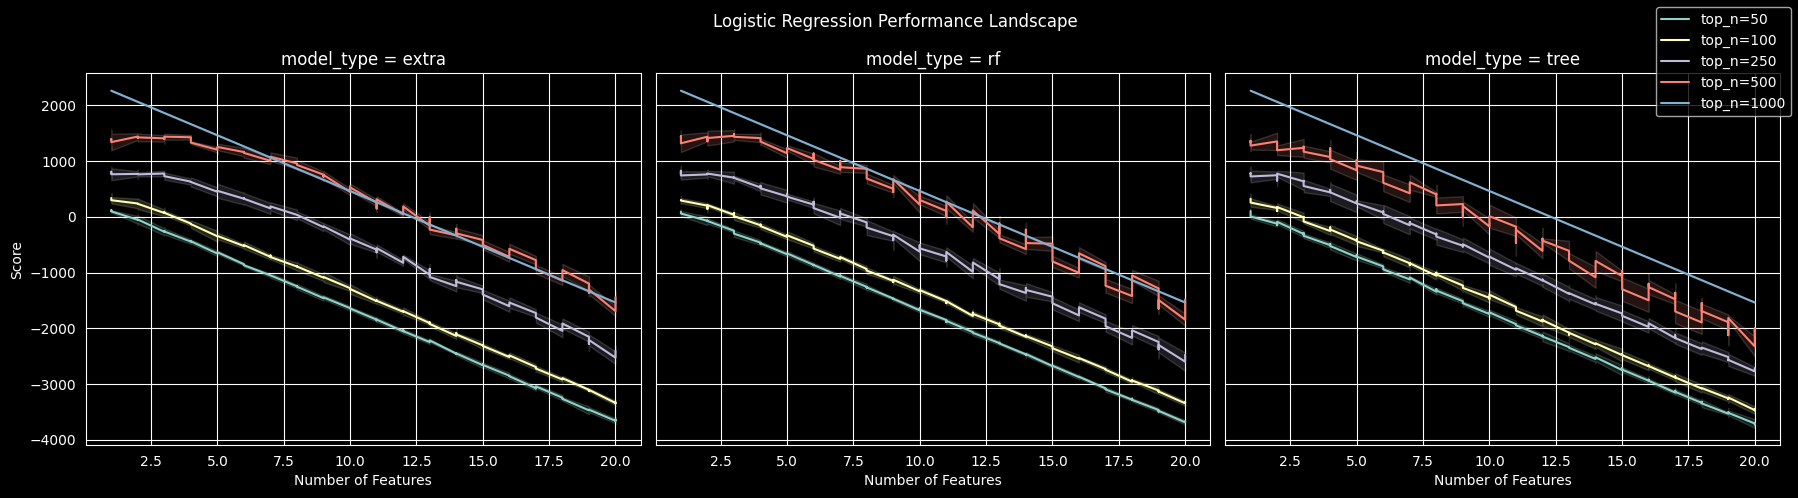

In [12]:
plot_metric_surface(
    df=final_results,
    x_col="n_features",
    y_col="score",
    split_col="model_type",
    line_col="top_n",
    std_col="score_std",
    title="Logistic Regression Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)